# Sistema neuronal confiable para concesión de crédito

Este notebook implementa un sistema de clasificación neuronal para el dataset **Home Credit Default Risk** con tres requisitos técnicos: rendimiento predictivo, aprendizaje justo respecto a `CODE_GENDER` e incertidumbre interpretable en test.

El flujo está pensado como informe ejecutable: cada bloque conecta una decisión técnica con una evidencia empírica. El modelo principal se entrena sobre el conjunto obligatorio de variables financieras y `EXT_SOURCE_*`; los contrastes adicionales se usan para auditar robustez, sensibilidad a la inicialización y potencial de mejora con más información.


## Mapa del notebook

El notebook sigue el orden de una auditoría técnica completa:

1. Definir el problema, las variables y las restricciones de evaluación.
2. Analizar desbalance, variable sensible, valores ausentes y calidad de `EXT_SOURCE_*`.
3. Construir un preprocesamiento sin leakage y auditable.
4. Entrenar una arquitectura custom con ratios financieros y ramas especializadas.
5. Situar la arquitectura final dentro de una progresión experimental M0-M6.
6. Aplicar FAIR loss, AutoML y barrido de `lambda_fair`.
7. Evaluar el trade-off precisión-justicia con Pareto principal y contraste multi-semilla.
8. Estimar incertidumbre con M2 y contrastarla con MC Dropout.
9. Analizar si la incertidumbre aumenta cuando faltan fuentes externas.
10. Cerrar con una ablación 12 vs 42 features y limitaciones para trabajo futuro.


## 0. Configuración global

Esta celda centraliza rutas, hiperparámetros principales y estilo visual. La ejecución profesional usa el dataset completo filtrado a `CODE_GENDER in {F, M}`.

Los parámetros elegidos son suficientemente serios para un MVP entregable: 15 trials de Keras Tuner, hasta 50 épocas y un barrido de 8 valores de `lambda_fair`.

In [1]:
from pathlib import Path
import sys
import os
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta del proyecto. Si el notebook se abre desde la raíz, esta ruta coincide con Path.cwd().
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS = PROJECT_ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
MODELS = RESULTS / "models"

for directory in (TABLES, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

# Aseguramos import local del paquete src.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reproducibilidad razonable para la ejecución. TensorFlow también se inicializa
# dentro de los entrenadores del proyecto, pero fijamos semillas desde el notebook.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Parámetros profesionales del MVP.
MAX_TRIALS = 15
EPOCHS = 50
BATCH_SIZE = 1024
LAMBDA_VALUES = (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0)

# Estilo visual sobrio y legible para informe/presentación.
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True
warnings.filterwarnings("ignore", category=FutureWarning)

def save_figure(name: str) -> Path:
    """Guarda la figura actual en results/figures con resolución de informe."""
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Kernel:", sys.executable)
print("MAX_TRIALS:", MAX_TRIALS, "EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE)

# Contrastes metodológicos secundarios. No sustituyen los resultados principales.
RUN_MC_DROPOUT = True
MC_DROPOUT_PASSES = 30
RUN_MULTI_SEED_PARETO = False
RUN_SQUARED_DP_SWEEP = False
ALPHA_SQUARED_DP_VALUES = (0.0, 5.0, 20.0)


PROJECT_ROOT: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani
Kernel: c:\venvs\homecredit311\Scripts\python.exe
MAX_TRIALS: 15 EPOCHS: 50 BATCH_SIZE: 1024


## 1. Problema, datos y contrato

El problema consiste en predecir `TARGET=1` (dificultades de pago) en solicitudes de credito. `CODE_GENDER` se trata como variable sensible para auditoria FAIR, y `EXT_SOURCE_1/2/3` son variables externas clave tanto para rendimiento como para incertidumbre.

Primero inventariamos los CSV disponibles para dejar claro que el MVP usa `application_train.csv` y que las tablas relacionales quedan reservadas para la extension avanzada.


In [2]:
csv_files = sorted(DATA_RAW.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No hay CSVs en {DATA_RAW}.")

inventory = pd.DataFrame({
    "archivo": [path.name for path in csv_files],
    "tamaño_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_files],
})
display(inventory.sort_values("archivo"))

,archivo,tamaño_mb
5,HomeCredit_columns_description.csv,0.04
7,POS_CASH_balance.csv,374.51
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
6,installments_payments.csv,689.62
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


## 2. Carga de datos principales

Cargamos la tabla principal con `TARGET`. Esta es la unica tabla necesaria para cumplir el MVP obligatorio; cualquier enriquecimiento posterior debe incorporarse con cuidado para evitar leakage temporal o mezcla accidental de informacion futura.


In [3]:
application_train_path = DATA_RAW / "application_train.csv"
if not application_train_path.exists():
    raise FileNotFoundError("Falta data/raw/application_train.csv")

raw = pd.read_csv(application_train_path)

print("Dimensiones application_train:", raw.shape)
display(raw.head())
display(raw[["TARGET", "CODE_GENDER", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].head())

Dimensiones application_train: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


,TARGET,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,M,202500.0,406597.5,24700.5,0.083037,0.262949,0.139376
1,0,F,270000.0,1293502.5,35698.5,0.311267,0.622246,NaN
2,0,M,67500.0,135000.0,6750.0,NaN,0.555912,0.729567
3,0,F,135000.0,312682.5,29686.5,NaN,0.650442,NaN
4,0,M,121500.0,513000.0,21865.5,NaN,0.322738,NaN


## 3. EDA: desbalance de clase y variable sensible

El objetivo esta fuertemente desbalanceado y la variable sensible no puede ignorarse. Por eso el notebook usa metricas basadas en ranking (`ROC-AUC`, `PR-AUC`), pesos de clase y metricas FAIR separadas de la metrica predictiva.


,proporción
TARGET,
0,0.91927
1,0.08073


,P(TARGET=0),P(TARGET=1)
CODE_GENDER,,
F,0.930007,0.069993
M,0.898581,0.101419


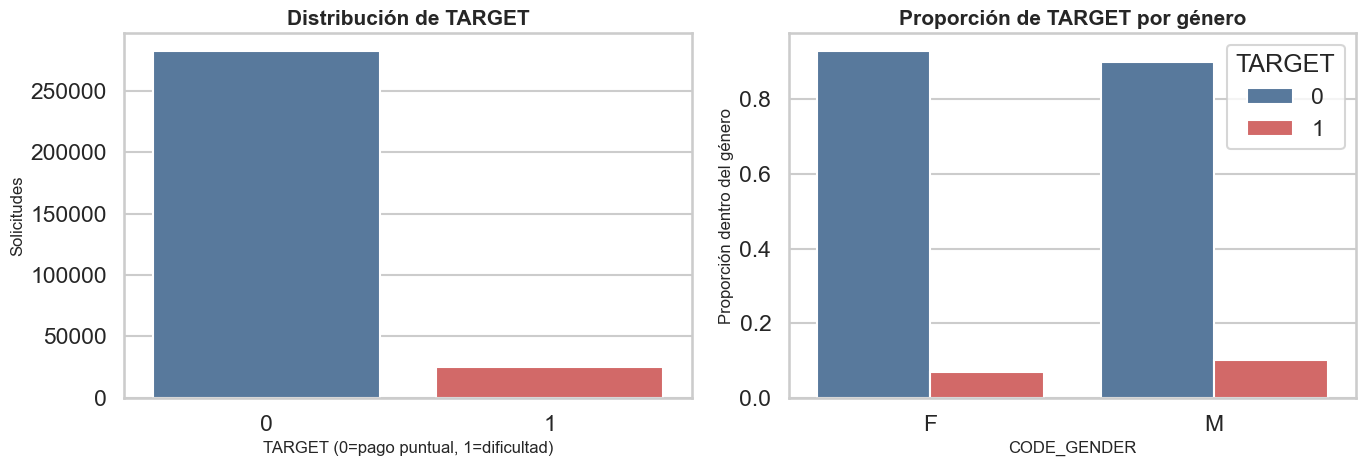

In [4]:
raw_fm = raw[raw["CODE_GENDER"].isin(["F", "M"])].copy()

target_summary = raw_fm["TARGET"].value_counts(normalize=True).rename("proporción").to_frame()
gender_target = pd.crosstab(raw_fm["CODE_GENDER"], raw_fm["TARGET"], normalize="index")
gender_target.columns = ["P(TARGET=0)", "P(TARGET=1)"]

display(target_summary)
display(gender_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=raw_fm, x="TARGET", ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Distribución de TARGET")
axes[0].set_xlabel("TARGET (0=pago puntual, 1=dificultad)")
axes[0].set_ylabel("Solicitudes")

gender_plot = raw_fm.groupby(["CODE_GENDER", "TARGET"]).size().reset_index(name="count")
gender_plot["prop"] = gender_plot.groupby("CODE_GENDER")["count"].transform(lambda s: s / s.sum())
sns.barplot(data=gender_plot, x="CODE_GENDER", y="prop", hue="TARGET", ax=axes[1], palette=["#4C78A8", "#E45756"])
axes[1].set_title("Proporción de TARGET por género")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Proporción dentro del género")

save_figure("eda_target_gender.png")
plt.show()

## 4. EDA: valores ausentes y calidad de fuentes externas

`EXT_SOURCE_*` combina poder predictivo con ausencia informativa. La ausencia de estas fuentes no es solo un problema de imputacion: tambien es una senal de menor calidad de informacion, por lo que se conserva `EXT_NULL_COUNT` para auditar incertidumbre.


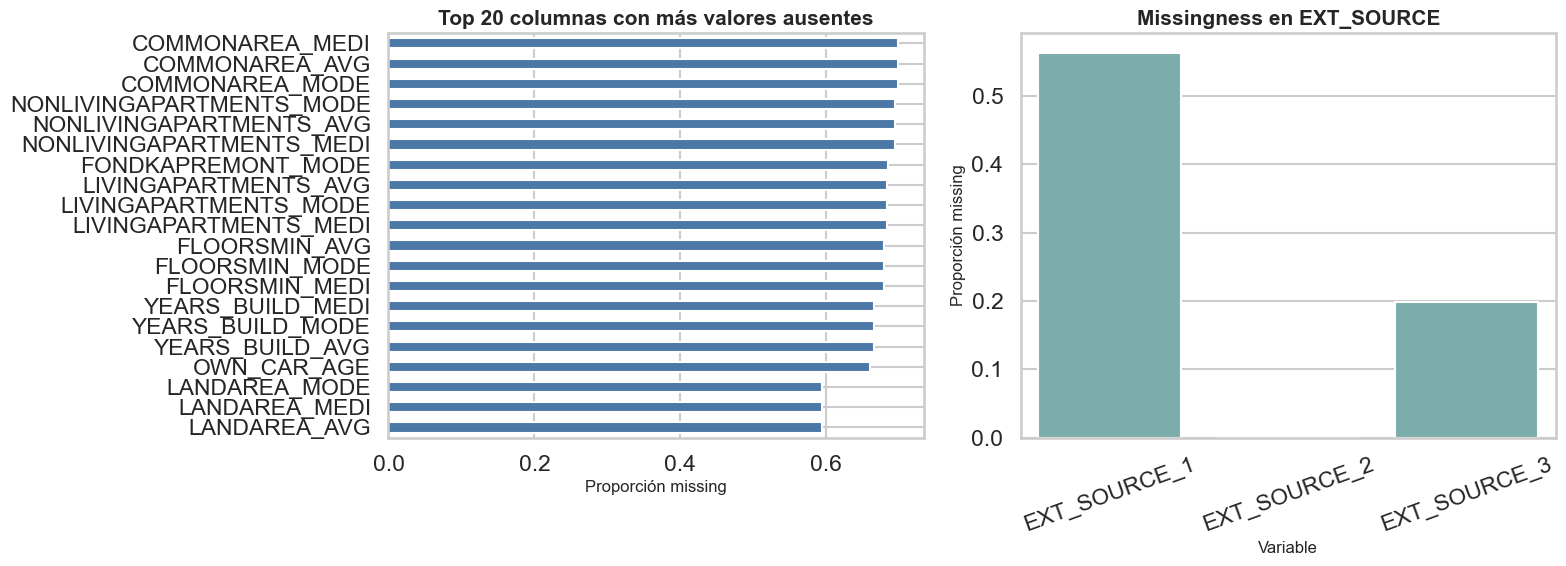

,proporción_missing
EXT_SOURCE_1,0.563812
EXT_SOURCE_2,0.002146
EXT_SOURCE_3,0.198256


In [5]:
missing = raw_fm.isna().mean().sort_values(ascending=False)
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
ext_missing = raw_fm[ext_cols].isna().mean().rename("proporción_missing")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

missing.head(20).sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 20 columnas con más valores ausentes")
axes[0].set_xlabel("Proporción missing")

sns.barplot(x=ext_missing.index, y=ext_missing.values, ax=axes[1], color="#72B7B2")
axes[1].set_title("Missingness en EXT_SOURCE")
axes[1].set_xlabel("Variable")
axes[1].set_ylabel("Proporción missing")
axes[1].tick_params(axis="x", rotation=20)

save_figure("eda_missingness_ext_source.png")
plt.show()

display(ext_missing.to_frame())

## 5. EDA: variables financieras y fuentes externas

Las variables monetarias tienen colas largas y las fuentes externas muestran relacion clara con el riesgo. El EDA justifica dos decisiones: usar ratios financieros en una capa custom y estudiar si el modelo duda mas cuando las fuentes externas son peores o faltan.


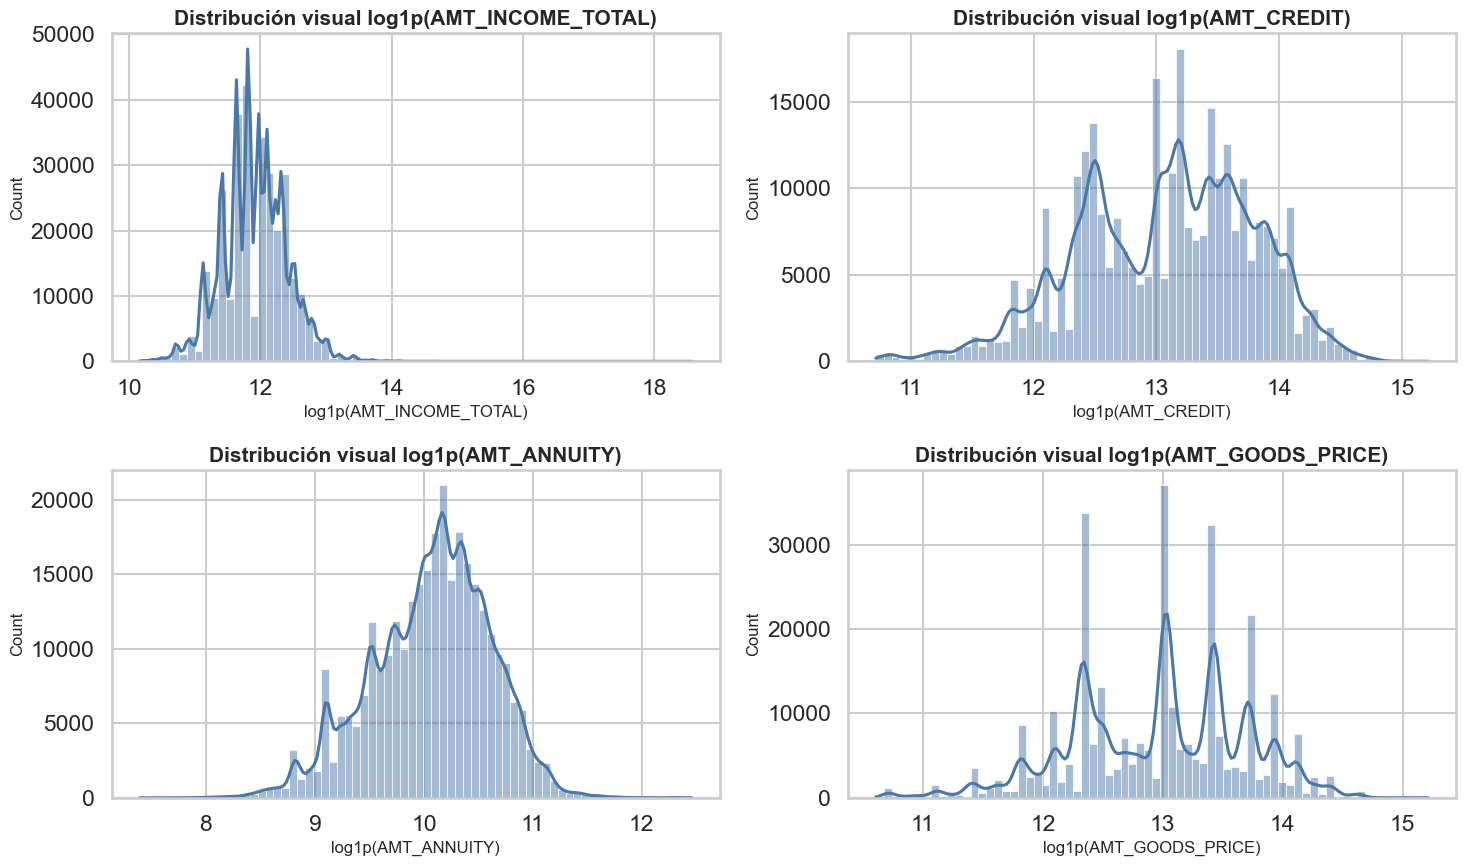

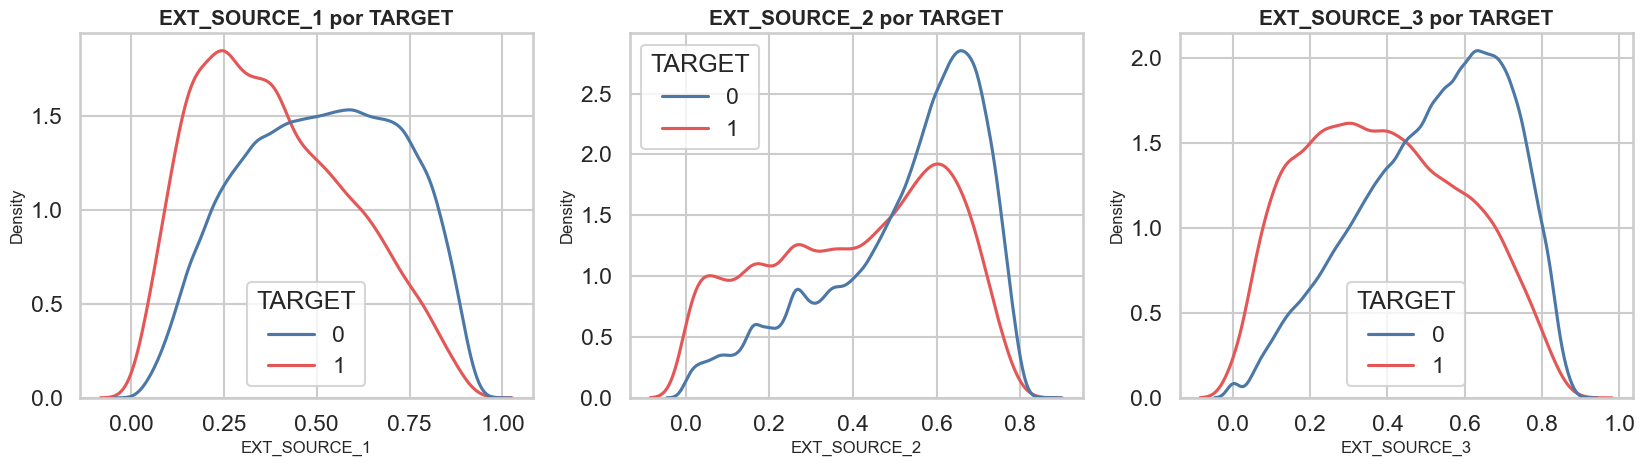

In [6]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for col, ax in zip(financial_cols, axes.ravel()):
    sns.histplot(np.log1p(raw_fm[col].dropna()), bins=70, kde=True, ax=ax, color="#4C78A8")
    ax.set_title(f"Distribución visual log1p({col})")
    ax.set_xlabel(f"log1p({col})")

save_figure("eda_financial_distributions.png")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for col, ax in zip(ext_cols, axes):
    sns.kdeplot(data=raw_fm, x=col, hue="TARGET", common_norm=False, ax=ax, palette=["#4C78A8", "#E45756"])
    ax.set_title(f"{col} por TARGET")

save_figure("eda_ext_source_by_target.png")
plt.show()

## 6. Preprocesamiento sin leakage

El pipeline transforma datos deterministas antes del split, ajusta imputadores/escaladores solo con train y preserva metadatos crudos para auditoria. La matriz procesada se usa para entrenar; los metadatos semanticos se usan para interpretar resultados.


In [7]:
from src.trustworthy_credit.preprocessing import HomeCreditMVPPreprocessingPipeline
from src.trustworthy_credit.splitting import HomeCreditTrainValTestSplitter, SplitConfig

pipeline = HomeCreditMVPPreprocessingPipeline()
raw_mvp = pipeline.load_raw(application_train_path)
deterministic = pipeline.apply_deterministic_transforms(raw_mvp)

splitter = HomeCreditTrainValTestSplitter(SplitConfig(test_size=0.15, validation_size=0.15, random_state=SEED))
split = splitter.split(deterministic)
processed = pipeline.fit_transform_splits(split.raw_splits)

print("raw_mvp:", raw_mvp.shape)
print("deterministic.features:", deterministic.features.shape)
print("X_train:", processed.X_train.shape)
print("X_val:", processed.X_val.shape)
print("X_test:", processed.X_test.shape)
display(split.report)

split.report.to_csv(TABLES / "split_report.csv", index=False)


raw_mvp: (307511, 18)
deterministic.features: (307507, 20)
X_train: (215254, 36)
X_val: (46126, 36)
X_test: (46127, 36)


,split,n,target_rate,sensitive_rate,target_0_sensitive_0,target_0_sensitive_1,target_1_sensitive_0,target_1_sensitive_1
0,train,215254,0.080733,0.341648,131794,66082,9919,7459
1,validation,46126,0.080714,0.341651,28242,14161,2125,1598
2,test,46127,0.080734,0.341644,28242,14161,2126,1598


## 7. Auditoría del preprocesamiento

Comprobamos que no hay NaNs tras imputación, que `CODE_GENDER` no entra como feature predictiva y que se conserva `EXT_NULL_COUNT` para el análisis de incertidumbre.

,valor
n_features,36
nan_X_train,0
nan_X_val,0
nan_X_test,0
CODE_GENDER_in_features,False
SENSITIVE_in_features,False
EXT_NULL_COUNT_in_features,True
EXT_NULL_COUNT_raw_values,"[0, 1, 2, 3]"


,feature_name
0,AMT_INCOME_TOTAL
1,AMT_CREDIT
2,AMT_ANNUITY
3,AMT_GOODS_PRICE
4,AGE_YEARS
5,EMPLOYED_YEARS
6,EXT_SOURCE_1
7,EXT_SOURCE_2
8,EXT_SOURCE_3
9,EXT_NULL_COUNT


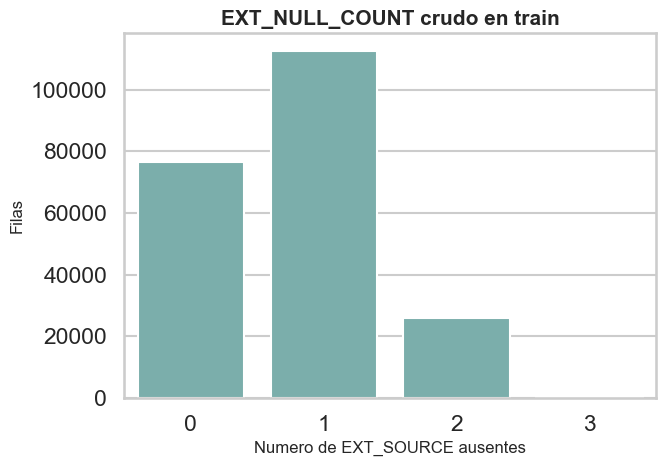

In [8]:
feature_names = tuple(processed.feature_names)

ext_null_values_train = processed.ext_null_count_train.astype(int)

assert set(ext_null_values_train).issubset({0, 1, 2, 3})

audit = {
    "n_features": len(feature_names),
    "nan_X_train": int(np.isnan(processed.X_train).sum()),
    "nan_X_val": int(np.isnan(processed.X_val).sum()),
    "nan_X_test": int(np.isnan(processed.X_test).sum()),
    "CODE_GENDER_in_features": "CODE_GENDER" in feature_names,
    "SENSITIVE_in_features": "SENSITIVE" in feature_names,
    "EXT_NULL_COUNT_in_features": "EXT_NULL_COUNT" in feature_names,
    "EXT_NULL_COUNT_raw_values": sorted(set(ext_null_values_train.tolist())),
}
display(pd.Series(audit, name="valor").to_frame())
display(pd.Series(feature_names, name="feature_name").head(80).to_frame())

plt.figure(figsize=(7, 5))
sns.countplot(x=ext_null_values_train, color="#72B7B2", order=[0, 1, 2, 3])
plt.title("EXT_NULL_COUNT crudo en train")
plt.xlabel("Numero de EXT_SOURCE ausentes")
plt.ylabel("Filas")
save_figure("preprocessing_ext_null_count.png")
plt.show()

## 8. Arquitectura customizada

La Tarea 1 exige una arquitectura con conocimiento de dominio. El modelo incorpora ratios financieros, transformaciones entrenables y una rama de penalizacion FAIR para separar tres conceptos: senal financiera, capacidad predictiva y dependencia con genero.

La arquitectura final no se elige por complejidad gratuita: se apoya en el EDA y se valida posteriormente con AutoML y Pareto.


In [9]:
from src.trustworthy_credit.models import CustomMLPModelBuilder

index_resolver = CustomMLPModelBuilder().index_resolver
ratio_indices = index_resolver.resolve(feature_names)

ratio_info = pd.DataFrame({
    "variable": ["AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL", "AMT_GOODS_PRICE"],
    "indice_procesado": list(ratio_indices.as_tuple()),
})
display(ratio_info)

,variable,indice_procesado
0,AMT_CREDIT,1
1,AMT_ANNUITY,2
2,AMT_INCOME_TOTAL,0
3,AMT_GOODS_PRICE,3


## 9. Progresión experimental M0-M6

Antes de fijar el pipeline final conviene situar la arquitectura en una progresión experimental. La idea no es reentrenar todos estos modelos dentro del notebook principal, sino documentar qué aporta cada familia de modelos: linealidad, profundidad, regularización, conocimiento financiero y separación de señales.

| Modelo | Idea técnica | Lectura para el MVP |
|---|---|---|
| M0 | Regresión logística | Baseline lineal: mide cuánto explica una frontera simple. |
| M1 | MLP con una capa oculta | Introduce interacciones no lineales básicas. |
| M2 | MLP con dos capas | Aumenta capacidad para relaciones no estrictamente lineales. |
| M3 | MLP + Dropout | Regulariza y suele ser el salto más eficaz en tabular neuronal. |
| M4/M5 | Capa financiera custom + scheduler | Introduce conocimiento de dominio y estabiliza convergencia. |
| M6 | Ramas custom para ratios y fuentes externas | Modelo auditable: separa señales financieras, `EXT_SOURCE_*` e interacciones densas. |

Esta progresión ayuda a defender que el modelo final no es una red arbitraria: cada componente que queda en el MVP responde a una hipótesis técnica concreta y a una necesidad del enunciado.


,model_id,model_name,epochs,best_epoch,history_best_val_auc,reported_val_auc,reported_test_auc,test_auc_gain_vs_m0,n_params
0,M0,Regresion logistica,35,20,0.7275,0.7275,0.7335,0.0000,13
1,M1,MLP 1 capa,69,54,0.7416,0.7416,0.7449,0.0114,897
2,M2,MLP 2 capas,24,9,0.7411,0.7411,0.7447,0.0112,9985
3,M3,MLP + Dropout,47,32,0.7424,0.7424,0.7452,0.0117,9985
4,M4,Capa financiera custom,47,32,0.7424,0.7424,0.7449,0.0114,9988
5,M5,Custom + scheduler,69,44,0.7428,0.7428,0.7449,0.0114,9988
6,M6,Dual custom,52,37,0.7421,0.7421,0.7451,0.0116,9991
7,M3 largo,MLP + Dropout largo,99,24,0.7419,0.7419,0.7457,0.0122,9985


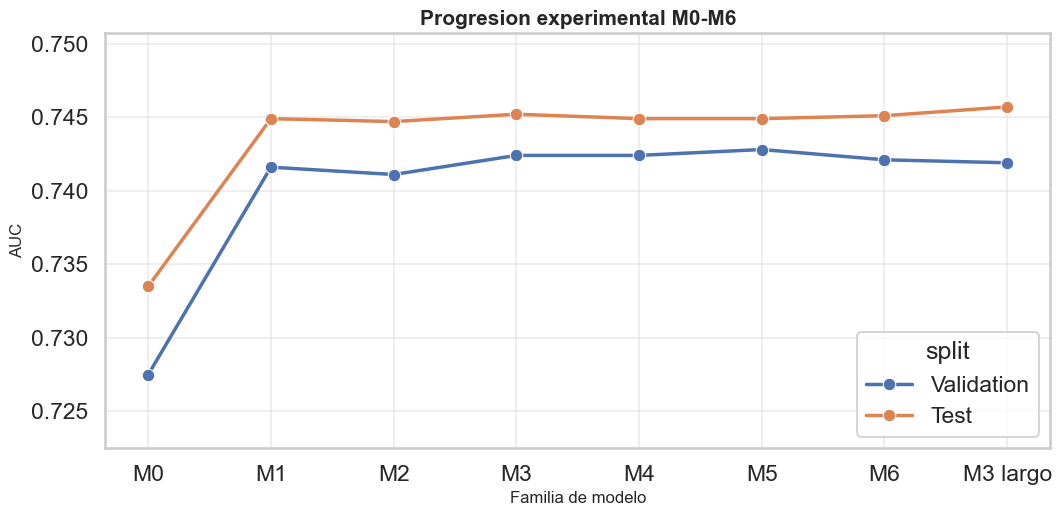

In [10]:
from src.trustworthy_credit.experiments import ModelProgressionReporter

progression_reporter = ModelProgressionReporter(
    checkpoints_dir=PROJECT_ROOT / "checkpoints",
)
model_progression = progression_reporter.summarize()
model_progression.to_csv(TABLES / "model_progression_m0_m6.csv", index=False)

progression_display = model_progression[[
    "model_id",
    "model_name",
    "epochs",
    "best_epoch",
    "history_best_val_auc",
    "reported_val_auc",
    "reported_test_auc",
    "test_auc_gain_vs_m0",
    "n_params",
]].copy()
progression_numeric = progression_display.select_dtypes(include="number").columns
progression_display[progression_numeric] = progression_display[progression_numeric].round(4)
display(progression_display)

progression_plot = model_progression.melt(
    id_vars=["model_id"],
    value_vars=["reported_val_auc", "reported_test_auc"],
    var_name="split",
    value_name="auc",
)
progression_plot["split"] = progression_plot["split"].map(
    {"reported_val_auc": "Validation", "reported_test_auc": "Test"}
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=progression_plot,
    x="model_id",
    y="auc",
    hue="split",
    marker="o",
    linewidth=2.5,
    ax=ax,
)
ax.set_title("Progresion experimental M0-M6")
ax.set_xlabel("Familia de modelo")
ax.set_ylabel("AUC")
ax.set_ylim(
    max(0.70, progression_plot["auc"].min() - 0.005),
    progression_plot["auc"].max() + 0.005,
)
ax.grid(alpha=0.3)
save_figure("model_progression_m0_m6_auc.png")
plt.show()


## 10. FAIR loss y objetivo de justicia

El objetivo FAIR es reducir la dependencia estadistica entre la prediccion y `CODE_GENDER` sin destruir la capacidad predictiva. El entrenamiento principal usa una perdida binaria de clasificacion y anade una penalizacion diferenciable de dependencia entre la probabilidad estimada y el atributo sensible.

La familia principal del MVP penaliza la correlacion de Pearson de batch al cuadrado. La auditoria posterior se reporta con `|rho|`, DPD y EOD, porque son mas faciles de interpretar en validacion y test. Como contraste metodologico, tambien dejamos implementada una perdida alternativa basada en Demographic Parity gap cuadratico.

| Variante | Forma conceptual | Que mide | Lectura practica |
|---|---|---|---|
| Pearson cuadratico principal | `BCE + lambda * rho(pred, G)^2` | Dependencia lineal diferenciable entre score y genero. | Es la ruta entrenada en el MVP y la que alimenta la Pareto principal. |
| DP gap cuadratico opcional | `BCE + alpha * (E[pred|G=1] - E[pred|G=0])^2` | Diferencia directa de probabilidad media entre grupos. | Es suave y muy interpretable; queda preparada para un sweep comparativo controlado. |
| Metricas de auditoria | `|rho|`, DPD, EOD | Dependencia de scores y diferencias de decision/error entre grupos. | Permiten evaluar el trade-off sin depender de una unica definicion de justicia. |

La lectura esperada no es maximizar una metrica aislada, sino construir una Pareto: cuanto AUC se sacrifica por cada reduccion de dependencia con la variable sensible.


In [11]:
from src.trustworthy_credit.fairness_losses import (
    SquaredDemographicParityConfig,
    SquaredDemographicParityLoss,
    make_augmented_fair_targets,
)

# Ejemplo pequeno y determinista: ilustra la penalizacion DP cuadratica sin
# entrenar ningun modelo adicional dentro del flujo principal.
synthetic_target = np.array([0, 0, 1, 1], dtype=np.float32)
synthetic_sensitive = np.array([0, 0, 1, 1], dtype=np.float32)
synthetic_predictions = np.array([[0.20], [0.30], [0.80], [0.90]], dtype=np.float32)
synthetic_augmented_target = make_augmented_fair_targets(
    synthetic_target,
    synthetic_sensitive,
)

squared_dp_loss = SquaredDemographicParityLoss(
    SquaredDemographicParityConfig(alpha=5.0)
)
squared_dp_components = squared_dp_loss.components(
    synthetic_augmented_target,
    synthetic_predictions,
)

squared_dp_demo = pd.DataFrame(
    [
        {
            "alpha": 5.0,
            "binary_crossentropy": float(squared_dp_components.binary_crossentropy.numpy()),
            "dp_gap": float(squared_dp_components.demographic_parity_gap.numpy()),
            "fairness_penalty": float(squared_dp_components.fairness_penalty.numpy()),
            "total_loss": float(squared_dp_components.total_loss.numpy()),
        }
    ]
)
display(squared_dp_demo.round(4))

if RUN_SQUARED_DP_SWEEP:
    print("RUN_SQUARED_DP_SWEEP=True: aqui se ejecutaria el sweep comparativo alpha.")
    print("Valores preparados:", ALPHA_SQUARED_DP_VALUES)
else:
    print("Sweep cuadratico desactivado por defecto para mantener estable el MVP ejecutable.")
    print("Valores preparados si se activa:", ALPHA_SQUARED_DP_VALUES)


,alpha,binary_crossentropy,dp_gap,fairness_penalty,total_loss
0,5.0,0.2271,0.6,1.8,2.0271


Sweep cuadratico desactivado por defecto para mantener estable el MVP ejecutable.
Valores preparados si se activa: (0.0, 5.0, 20.0)


## 11. AutoML con Keras Tuner

Keras Tuner busca la topologia de la red con una presion FAIR moderada. Despues se fija la mejor arquitectura y se estudia `lambda_fair` en una familia controlada de modelos.


In [12]:
from src.trustworthy_credit.tuning import FairKerasTunerRunner, FairLambdaSweepTrainer, TuningArtifactPaths, TuningConfig

tuning_config = TuningConfig(
    tuning_lambda_fair=0.5,
    lambda_values=LAMBDA_VALUES,
    max_trials=MAX_TRIALS,
    executions_per_trial=1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    early_stopping_patience=10,
    reduce_lr_patience=5,
    tuner_project_name="fair_credit_mvp_professional",
    overwrite_tuner=True,
)


La celda anterior define la configuración. La siguiente celda ejecuta la búsqueda y puede tardar. Si se interrumpe, se puede relanzar desde aquí.

In [13]:
# Configuración de rutas para artefactos de tuning.
artifacts = TuningArtifactPaths(project_root=PROJECT_ROOT)

tuner_runner = FairKerasTunerRunner(config=tuning_config, artifacts=artifacts)
search_result = tuner_runner.search(processed, verbose=1)

print("Mejor arquitectura encontrada:")
print("hidden_units:", search_result.best_config.hidden_units)
print("activation:", search_result.best_config.activation)
print("dropout:", search_result.best_config.dropout)
print("learning_rate:", search_result.best_config.learning_rate)

Trial 15 Complete [00h 01m 23s]
val_auc: 0.7374807000160217

Best val_auc So Far: 0.7443267107009888
Total elapsed time: 00h 14m 33s
Mejor arquitectura encontrada:
hidden_units: (256, 64, 128, 128)
activation: elu
dropout: 0.2
learning_rate: 0.000978041751919679


## 12. Barrido de `lambda_fair`

Con la arquitectura ganadora, entrenamos una familia de modelos donde solo cambia el peso de la penalizacion FAIR. Esta comparacion controlada permite interpretar el coste real de reducir dependencia con genero.


In [14]:
sweep_trainer = FairLambdaSweepTrainer(config=tuning_config, artifacts=artifacts)

sweep_result = sweep_trainer.run(
    data=processed,
    custom_config=search_result.best_config,
    ratio_indices=search_result.ratio_indices,
    class_weight=search_result.class_weight,
    save_models=True,
    verbose=1,
)

pareto = pd.read_csv(TABLES / "pareto_results.csv")
display(pareto)

Epoch 1/50
211/211 [==============================] - 4s 12ms/step - loss: 0.6136 - auc: 0.7259 - pr_auc: 0.1962 - binary_accuracy: 0.6647 - precision: 0.1498 - recall: 0.6744 - val_loss: 0.6569 - val_auc: 0.7312 - val_pr_auc: 0.2187 - val_binary_accuracy: 0.6241 - val_precision: 0.1407 - val_recall: 0.7161 - lr: 9.7804e-04 - val_abs_rho: 0.0625
Epoch 2/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6036 - auc: 0.7374 - pr_auc: 0.2058 - binary_accuracy: 0.6743 - precision: 0.1550 - recall: 0.6813 - val_loss: 0.6200 - val_auc: 0.7344 - val_pr_auc: 0.2231 - val_binary_accuracy: 0.6593 - val_precision: 0.1489 - val_recall: 0.6831 - lr: 9.7804e-04 - val_abs_rho: 0.0937
Epoch 3/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6022 - auc: 0.7392 - pr_auc: 0.2089 - binary_accuracy: 0.6744 - precision: 0.1550 - recall: 0.6817 - val_loss: 0.6201 - val_auc: 0.7379 - val_pr_auc: 0.2243 - val_binary_accuracy: 0.6652 - val_precision: 0.1516 - val_recall: 0.

,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


## 13. Pareto principal: rendimiento vs dependencia FAIR

Esta figura responde al requisito obligatorio de trade-off. El punto ideal estaria arriba a la izquierda: alto `val_auc` y baja dependencia con genero (`val_abs_rho`). La seleccion final prioriza una reduccion muy fuerte de dependencia con una perdida moderada de AUC.


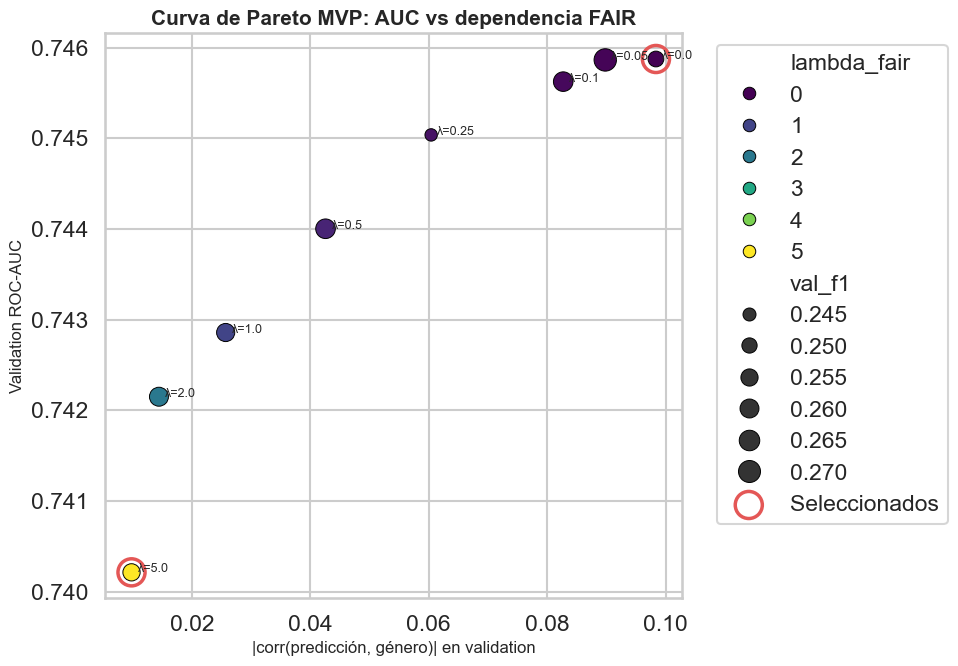

In [15]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=pareto,
    x="val_abs_rho",
    y="val_auc",
    hue="lambda_fair",
    size="val_f1",
    sizes=(80, 260),
    palette="viridis",
    edgecolor="black",
    linewidth=0.7,
)

for _, row in pareto.iterrows():
    label = f"λ={row['lambda_fair']}"
    plt.text(row["val_abs_rho"] + 0.001, row["val_auc"], label, fontsize=9)

selected = pareto[pareto["selected_for_test"] == True]
plt.scatter(selected["val_abs_rho"], selected["val_auc"], s=380, facecolors="none", edgecolors="#E45756", linewidths=2.5, label="Seleccionados")

plt.title("Curva de Pareto MVP: AUC vs dependencia FAIR")
plt.xlabel("|corr(predicción, género)| en validation")
plt.ylabel("Validation ROC-AUC")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
save_figure("pareto_auc_vs_fairness.png")
plt.show()

## 14. Robustez de Pareto: contraste multi-semilla

La Pareto principal se obtiene con una ejecución completa del pipeline. Como control de robustez, esta sección lee una tabla multi-semilla ya calculada cuando existe y representa la media con desviación típica. Esto estima sensibilidad a inicialización sin reentrenar modelos largos dentro del notebook final.

Si la tabla no existe, el notebook no falla: deja preparada la configuración y conserva como evidencia principal la Pareto canónica generada por el barrido de `lambda_fair`.


,lambda_fair,auc_mean,auc_std,abs_rho_mean,abs_rho_std,mean_F,mean_M,n_runs,auc_delta_vs_baseline,fairness_reduction
0,0.0,0.7465,0.0002,0.0295,0.0004,0.0699,0.0994,3,0.0000,0.0000
1,0.1,0.7438,0.0004,0.0084,0.0015,0.0753,0.0837,3,-0.0027,0.7158
2,0.5,0.7425,0.0005,0.0051,0.0019,0.0780,0.0831,3,-0.0039,0.8288
3,1.0,0.7417,0.0006,0.0028,0.0020,0.0750,0.0778,3,-0.0048,0.9052
4,2.0,0.7396,0.0007,0.0035,0.0013,0.0733,0.0768,3,-0.0069,0.8815
5,5.0,0.7351,0.0003,0.0014,0.0008,0.0718,0.0732,3,-0.0114,0.9512


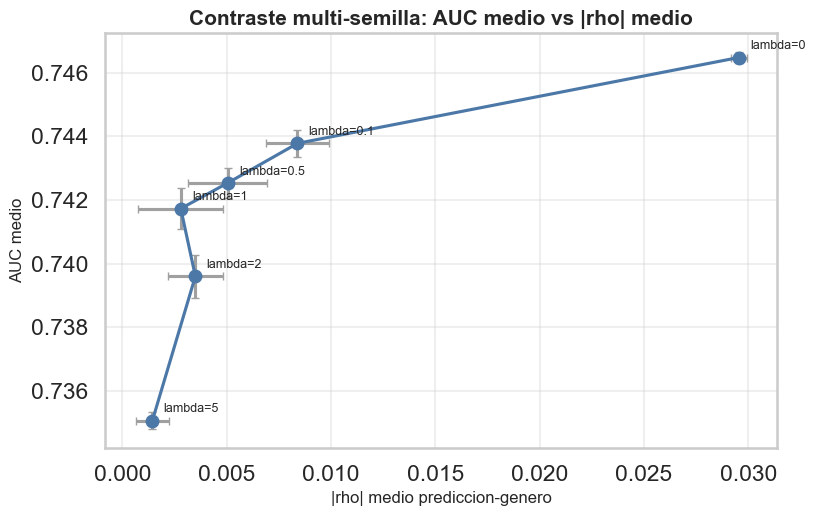

In [16]:
from src.trustworthy_credit.experiments import (
    MultiSeedParetoArtifactReporter,
    MultiSeedParetoConfig,
)

multi_seed_config = MultiSeedParetoConfig(
    seeds=(42, 123, 7),
    lambda_values=tuple(float(value) for value in LAMBDA_VALUES),
)
multi_seed_candidates = [
    TABLES / "pareto_multiseed_results.csv",
    PROJECT_ROOT / "checkpoints" / "pareto_v2_results.csv",
]
multi_seed_path = next((path for path in multi_seed_candidates if path.exists()), None)

if multi_seed_path is None:
    print("No se ha encontrado una tabla multi-semilla ya calculada.")
    print("Configuracion preparada para ejecucion futura:")
    print(multi_seed_config)
    print("La Pareto canonica del MVP sigue siendo pareto_results.csv.")
else:
    multi_seed_summary = MultiSeedParetoArtifactReporter(
        config=multi_seed_config,
    ).summarize(multi_seed_path)
    multi_seed_summary.to_csv(TABLES / "pareto_multiseed_summary.csv", index=False)

    multi_seed_display = multi_seed_summary.copy()
    multi_seed_numeric = multi_seed_display.select_dtypes(include="number").columns
    multi_seed_display[multi_seed_numeric] = multi_seed_display[multi_seed_numeric].round(4)
    display(multi_seed_display)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.errorbar(
        multi_seed_summary["abs_rho_mean"],
        multi_seed_summary["auc_mean"],
        xerr=multi_seed_summary.get("abs_rho_std"),
        yerr=multi_seed_summary.get("auc_std"),
        fmt="o-",
        color="#4C78A8",
        ecolor="#A0A0A0",
        capsize=3,
    )
    for _, row in multi_seed_summary.iterrows():
        ax.annotate(
            f"lambda={row['lambda_fair']:g}",
            (row["abs_rho_mean"], row["auc_mean"]),
            textcoords="offset points",
            xytext=(8, 6),
            fontsize=9,
        )
    ax.set_title("Contraste multi-semilla: AUC medio vs |rho| medio")
    ax.set_xlabel("|rho| medio prediccion-genero")
    ax.set_ylabel("AUC medio")
    ax.grid(alpha=0.3)
    save_figure("pareto_multiseed_contrast.png")
    plt.show()


## 15. Selección de modelos finales

Para evaluación final se usan dos modelos de la misma familia dual-input:

- Base final: `lambda_fair=0.0`.
- FAIR final: modelo FAIR seleccionado en validation.

In [18]:
base_row = pareto[np.isclose(pareto["lambda_fair"], 0.0)].iloc[0]

fair_selected = pareto[(pareto["selected_for_test"] == True) & (~np.isclose(pareto["lambda_fair"], 0.0))]
if fair_selected.empty:
    fair_selected = pareto[~np.isclose(pareto["lambda_fair"], 0.0)].sort_values(["val_abs_rho", "val_auc"], ascending=[True, False]).head(1)
fair_row = fair_selected.iloc[0]

display(pd.DataFrame([base_row, fair_row], index=["Base final", "FAIR final"]))

,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
Base final,0.0,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
FAIR final,5.0,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


## 16. Curvas de convergencia

Las curvas de loss y AUC verifican que los modelos finales han entrenado de forma estable. Esta evidencia es obligatoria para defender que los resultados no son un artefacto de una ejecucion incompleta.


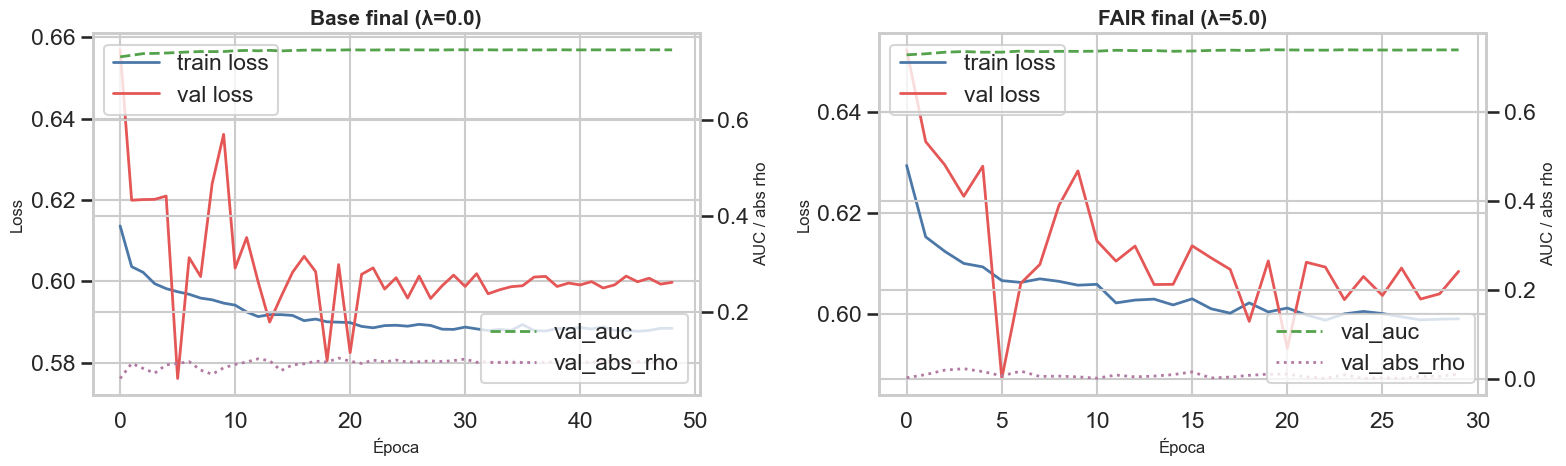

In [19]:
final_rows = pd.DataFrame([base_row, fair_row], index=["Base final", "FAIR final"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, row) in zip(axes, final_rows.iterrows()):
    history = pd.read_csv(PROJECT_ROOT / row["history_path"])
    ax.plot(history["loss"], label="train loss", color="#4C78A8", linewidth=2)
    ax.plot(history["val_loss"], label="val loss", color="#E45756", linewidth=2)
    ax.set_title(f"{name} (λ={row['lambda_fair']})")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    if "val_auc" in history.columns:
        ax2.plot(history["val_auc"], label="val_auc", color="#54A24B", linestyle="--", linewidth=2)
    if "val_abs_rho" in history.columns:
        ax2.plot(history["val_abs_rho"], label="val_abs_rho", color="#B279A2", linestyle=":", linewidth=2)
    ax2.set_ylabel("AUC / abs rho")
    ax2.legend(loc="lower right")

save_figure("training_curves_base_vs_fair.png")
plt.show()

## 17. Evaluación final en test

El test no se usó para elegir arquitectura, lambda ni threshold. Ahora evaluamos base final y FAIR final en test usando el threshold elegido en validation para cada modelo.

In [20]:
from src.trustworthy_credit.uncertainty import FairModelLoader
from src.trustworthy_credit.tuning import DualInputFormatter
from src.trustworthy_credit.metrics import ProbabilityMetricCalculator, BinaryClassificationMetricCalculator, FairnessMetricCalculator

formatter = DualInputFormatter()
loader = FairModelLoader()
prob_calc = ProbabilityMetricCalculator()
bin_calc = BinaryClassificationMetricCalculator()
fair_calc = FairnessMetricCalculator()

def predict_dual(model, X, s):
    """Predice probabilidades con un modelo dual-input features+sensitive."""
    return model.predict(formatter.format(X, s), batch_size=BATCH_SIZE, verbose=0).reshape(-1)

def evaluate_on_test(row, model_name):
    """Evalúa un modelo final en test con el threshold elegido en validation."""
    model = loader.load(PROJECT_ROOT / row["model_path"])
    proba = predict_dual(model, processed.X_test, processed.s_test)
    threshold = float(row["val_threshold"])
    prob = prob_calc.calculate(processed.y_test, proba, processed.s_test)
    binary = bin_calc.calculate(processed.y_test, proba, threshold)
    fairness = fair_calc.calculate(processed.y_test, proba, processed.s_test, threshold)
    return {
        "modelo": model_name,
        "lambda_fair": float(row["lambda_fair"]),
        "threshold": threshold,
        "auc": prob.roc_auc,
        "pr_auc": prob.pr_auc,
        "accuracy": binary.accuracy,
        "precision": binary.precision,
        "recall": binary.recall,
        "f1": binary.f1,
        "abs_rho": prob.abs_rho,
        "dpd": fairness.demographic_parity_difference,
        "eod": fairness.equalized_odds_difference,
        "y_proba": proba,
    }

base_eval = evaluate_on_test(base_row, "Base final")
fair_eval = evaluate_on_test(fair_row, "FAIR final")

test_results = pd.DataFrame([{k: v for k, v in item.items() if k != "y_proba"} for item in [base_eval, fair_eval]])
test_results.to_csv(TABLES / "test_results_base_vs_fair.csv", index=False)
display(test_results)

,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.481516,0.743631,0.222811,0.657186,0.150990,0.702202,0.248539,0.097065,0.088874,0.080517
1,FAIR final,5.0,0.500768,0.738022,0.218571,0.674291,0.154138,0.676155,0.251047,0.008850,0.024762,0.015300


## 18. Comparativa visual en test

La comparativa resume el intercambio principal: el modelo FAIR sacrifica una pequena parte de rendimiento para reducir de forma notable la dependencia con genero y las diferencias de comportamiento entre grupos.


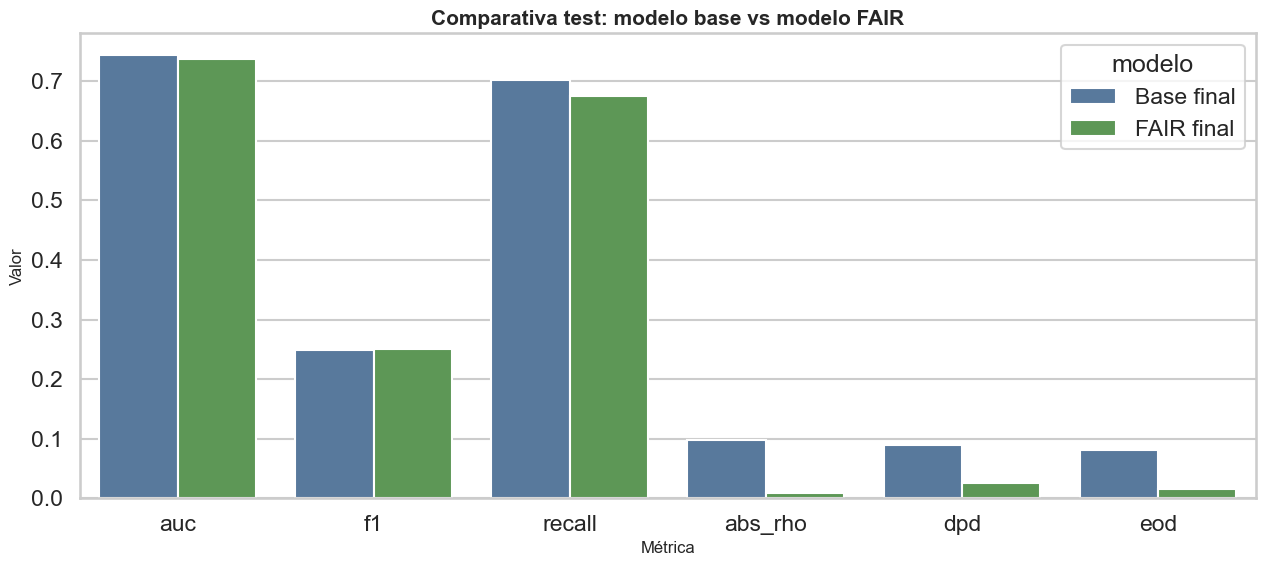

In [21]:
plot_metrics = ["auc", "f1", "recall", "abs_rho", "dpd", "eod"]
plot_df = test_results.melt(id_vars="modelo", value_vars=plot_metrics, var_name="métrica", value_name="valor")

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="métrica", y="valor", hue="modelo", palette=["#4C78A8", "#54A24B"])
plt.title("Comparativa test: modelo base vs modelo FAIR")
plt.xlabel("Métrica")
plt.ylabel("Valor")
save_figure("test_metrics_base_vs_fair.png")
plt.show()

## 19. Incertidumbre principal: modelo M2

La Tarea 4 se resuelve con un modelo secundario M2 que aprende el error absoluto esperado del clasificador FAIR. En test, M2 devuelve una incertidumbre por solicitante: cuanto mayor sea, mas recomendable es una revision humana.


In [22]:
from src.trustworthy_credit.uncertainty import UncertaintyMVPTrainer, UncertaintyModelConfig, UncertaintyArtifactPaths

fair_model = loader.load(PROJECT_ROOT / fair_row["model_path"])

uncertainty_trainer = UncertaintyMVPTrainer(
    config=UncertaintyModelConfig(
        hidden_units=(32,),
        dropout=0.3,
        output_activation="softplus",
        normalize_inputs=True,
        batch_size=BATCH_SIZE,
        epochs=50,
        early_stopping_patience=10,
    ),
    artifacts=UncertaintyArtifactPaths(project_root=PROJECT_ROOT),
)

uncertainty_result = uncertainty_trainer.run(
    m1_model=fair_model,
    data=processed,
    selected_threshold=float(fair_row["val_threshold"]),
    save_artifacts=True,
    save_model=True,
    verbose=1,
)

unc = pd.read_csv(TABLES / "uncertainty_test.csv")
unc_summary = pd.read_csv(TABLES / "uncertainty_summary_by_target.csv")
unc["EXT_NULL_COUNT"] = unc["EXT_NULL_COUNT"].astype(int)

assert unc["uncertainty"].nunique() > 1, "M2 produjo incertidumbre constante."
assert set(unc["EXT_NULL_COUNT"].unique()).issubset({0, 1, 2, 3})

display(unc.head())
display(unc_summary)

Epoch 1/50
37/37 [==============================] - 0s 3ms/step - loss: 0.2001 - val_loss: 0.1272
Epoch 2/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1504 - val_loss: 0.0971
Epoch 3/50
37/37 [==============================] - 0s 1ms/step - loss: 0.1231 - val_loss: 0.0803
Epoch 4/50
37/37 [==============================] - 0s 2ms/step - loss: 0.1053 - val_loss: 0.0707
Epoch 5/50
37/37 [==============================] - 0s 1ms/step - loss: 0.0932 - val_loss: 0.0647
Epoch 6/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0844 - val_loss: 0.0607
Epoch 7/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0796 - val_loss: 0.0580
Epoch 8/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0757 - val_loss: 0.0558
Epoch 9/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0724 - val_loss: 0.0537
Epoch 10/50
37/37 [==============================] - 0s 2ms/step - loss: 0.0695 - val_loss: 0.0520
Epoch 11/50
37/37 [

,SK_ID_CURR,y_true,y_proba,y_pred_label,sensitive,threshold,uncertainty,EXT_NULL_COUNT
0,115177,0,0.396257,0,0,0.500768,0.397690,0
1,353727,0,0.219442,0,0,0.500768,0.213308,0
2,430036,0,0.759136,1,1,0.500768,0.718447,1
3,300897,0,0.815262,1,0,0.500768,0.764503,1
4,135159,0,0.311581,0,1,0.500768,0.309126,0


,y_true,count,uncertainty_mean,uncertainty_median,uncertainty_q1,uncertainty_q3,uncertainty_iqr
0,0,42403,0.404643,0.388936,0.241310,0.554719,0.313408
1,1,3724,0.573916,0.604027,0.445224,0.724008,0.278784


## 20. Contraste de incertidumbre: MC Dropout

MC Dropout mantiene dropout activo en inferencia y estima varianza entre pasadas estocasticas. Se incluye como contraste secundario: no sustituye M2, pero ayuda a comprobar si otro enfoque tambien detecta peor calidad de informacion externa.


,artifact,n_samples,mean_prediction,median_prediction,mean_variance,median_variance,p95_variance
0,mc_m6,61502,0.423230,0.400603,0.001412,0.001254,0.002763
1,mc_fair,61502,0.078714,0.057693,0.000165,0.000081,0.000593
2,mc_fair10,61502,0.077212,0.058662,0.000137,0.000067,0.000481


,model,point_auc,mc_mean_auc,variance_target_0,variance_target_1,target_1_to_0_variance_ratio,variance_ext_missing_0,variance_ext_missing_3,ext_missing_3_lift_vs_0
0,M6 base,0.7451,0.7455,0.001422,0.001306,0.918425,0.001472,0.001414,-0.039402
1,FAIR lambda=1.0,0.7424,0.7428,0.000123,0.000301,2.447154,0.000134,0.000241,0.798507


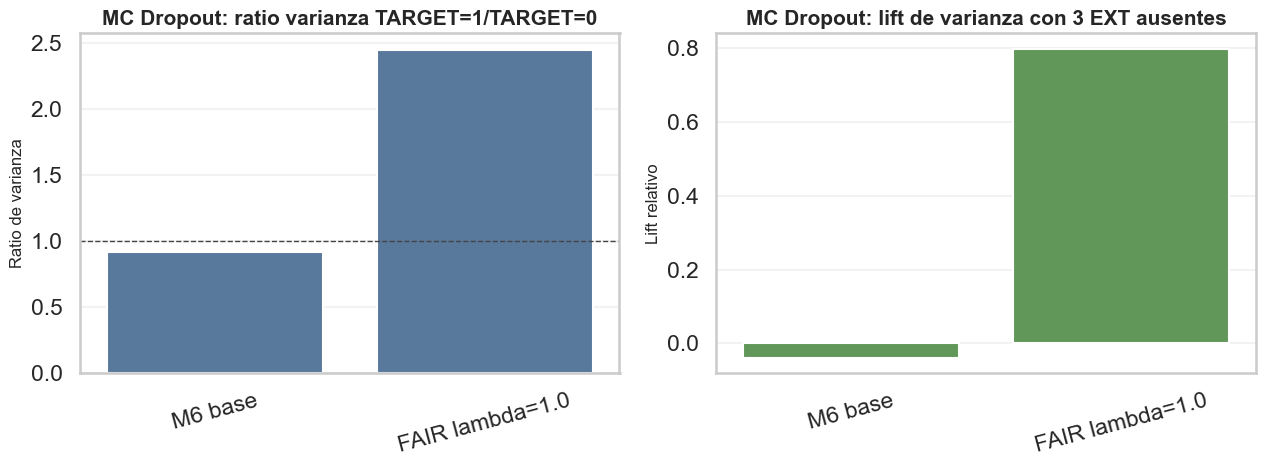

In [23]:
from src.trustworthy_credit.experiments import MCDropoutArtifactReporter

mc_artifact_reporter = MCDropoutArtifactReporter(
    checkpoints_dir=PROJECT_ROOT / "checkpoints",
)
mc_saved_arrays = mc_artifact_reporter.saved_array_summary()
mc_audited_summary = mc_artifact_reporter.audited_summary()

if mc_saved_arrays.empty:
    print("No se han encontrado arrays MC Dropout guardados en checkpoints/.")
else:
    mc_saved_arrays.to_csv(TABLES / "mc_dropout_saved_array_summary.csv", index=False)
    mc_saved_display = mc_saved_arrays.copy()
    mc_saved_numeric = mc_saved_display.select_dtypes(include="number").columns
    mc_saved_display[mc_saved_numeric] = mc_saved_display[mc_saved_numeric].round(6)
    display(mc_saved_display)

mc_audited_summary.to_csv(TABLES / "mc_dropout_audited_summary.csv", index=False)
mc_audited_display = mc_audited_summary.copy()
mc_audited_numeric = mc_audited_display.select_dtypes(include="number").columns
mc_audited_display[mc_audited_numeric] = mc_audited_display[mc_audited_numeric].round(6)
display(mc_audited_display)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=mc_audited_summary,
    x="model",
    y="target_1_to_0_variance_ratio",
    color="#4C78A8",
    ax=axes[0],
)
sns.barplot(
    data=mc_audited_summary,
    x="model",
    y="ext_missing_3_lift_vs_0",
    color="#59A14F",
    ax=axes[1],
)
axes[0].axhline(1.0, color="#444444", linestyle="--", linewidth=1)
axes[0].set_title("MC Dropout: ratio varianza TARGET=1/TARGET=0")
axes[1].set_title("MC Dropout: lift de varianza con 3 EXT ausentes")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[0].set_ylabel("Ratio de varianza")
axes[1].set_ylabel("Lift relativo")
for axis in axes:
    axis.tick_params(axis="x", rotation=15)
    axis.grid(alpha=0.25, axis="y")
save_figure("mc_dropout_audited_contrast.png")
plt.show()


MC Dropout completado con 30 pasadas estocasticas.
Varianza unica: 46058 valores distintos


,y_true,count,mean_variance,median_variance
0,0.0,42403,0.001196,0.001082
1,1.0,3724,0.001132,0.001003


,EXT_NULL_COUNT,count,mean_variance,median_variance
0,0,16448,0.001167,0.001054
1,1,24140,0.001151,0.001045
2,2,5511,0.001428,0.001303
3,3,28,0.002640,0.002677


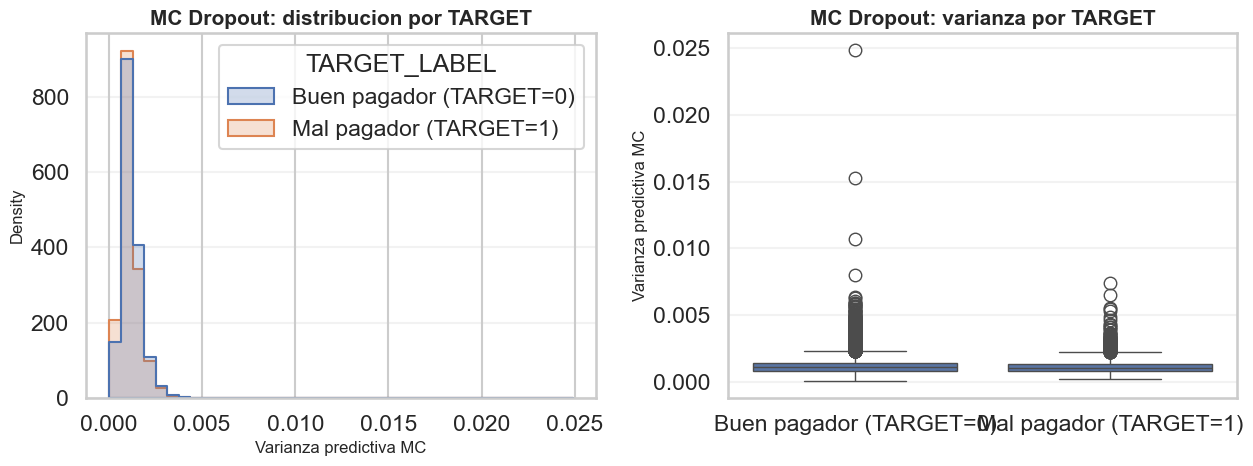

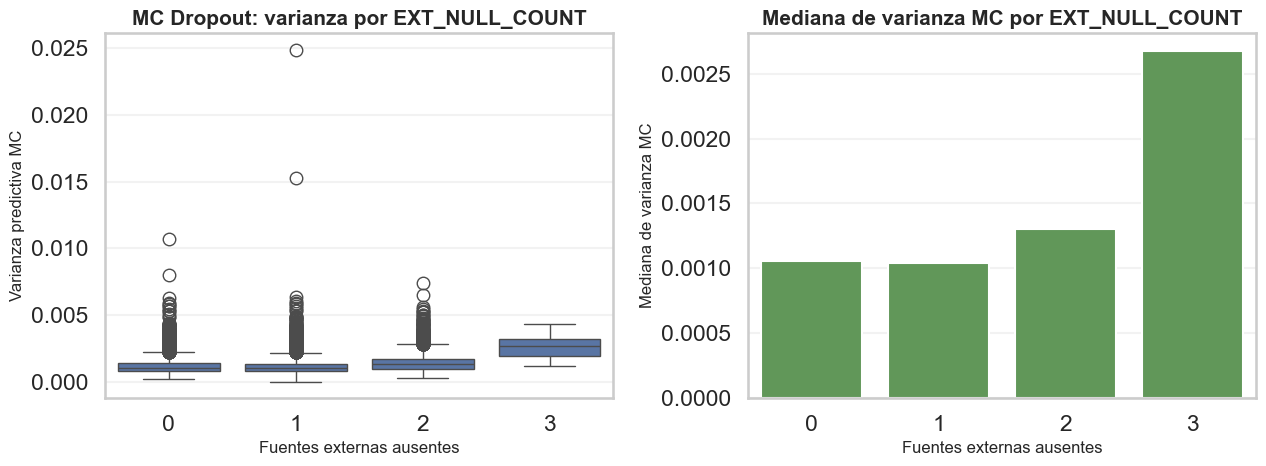

In [24]:
from src.trustworthy_credit.uncertainty_mc import (
    MCDropoutConfig,
    MCDropoutSummaryBuilder,
    MCDropoutUncertaintyEstimator,
)

if RUN_MC_DROPOUT:
    mc_config = MCDropoutConfig(
        n_passes=MC_DROPOUT_PASSES,
        batch_size=BATCH_SIZE,
        threshold=float(fair_row["val_threshold"]),
        random_seed=SEED,
    )
    mc_estimator = MCDropoutUncertaintyEstimator(config=mc_config)
    mc_result = mc_estimator.predict(
        fair_model,
        processed.X_test,
        sensitive=processed.s_test,
        keep_all_passes=False,
    )

    mc_summary_builder = MCDropoutSummaryBuilder()
    mc_dropout_test = mc_summary_builder.to_frame(
        mc_result,
        y_true=processed.y_test,
        ext_null_count=processed.ext_null_count_test,
    )
    mc_dropout_test.to_csv(TABLES / "mc_dropout_test.csv", index=False)

    mc_target_summary = mc_summary_builder.summary_by_target(
        mc_result,
        processed.y_test,
    )
    mc_ext_summary = mc_summary_builder.summary_by_ext_null_count(
        mc_result,
        processed.ext_null_count_test,
    )
    mc_target_summary.to_csv(TABLES / "mc_dropout_by_target.csv", index=False)
    mc_ext_summary.to_csv(TABLES / "mc_dropout_by_ext_null_count.csv", index=False)

    print(f"MC Dropout completado con {MC_DROPOUT_PASSES} pasadas estocasticas.")
    print(f"Varianza unica: {mc_dropout_test['mc_variance'].nunique()} valores distintos")
    display(mc_target_summary)
    display(mc_ext_summary)

    mc_plot_df = mc_dropout_test.copy()
    mc_plot_df["TARGET_LABEL"] = mc_plot_df["y_true"].map(
        {0: "Buen pagador (TARGET=0)", 1: "Mal pagador (TARGET=1)"}
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(
        data=mc_plot_df,
        x="mc_variance",
        hue="TARGET_LABEL",
        stat="density",
        common_norm=False,
        bins=40,
        element="step",
        ax=axes[0],
    )
    sns.boxplot(data=mc_plot_df, x="TARGET_LABEL", y="mc_variance", ax=axes[1])
    axes[0].set_title("MC Dropout: distribucion por TARGET")
    axes[1].set_title("MC Dropout: varianza por TARGET")
    axes[0].set_xlabel("Varianza predictiva MC")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Varianza predictiva MC")
    for axis in axes:
        axis.grid(alpha=0.25, axis="y")
    save_figure("mc_dropout_uncertainty_by_target.png")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.boxplot(data=mc_plot_df, x="EXT_NULL_COUNT", y="mc_variance", ax=axes[0])
    sns.barplot(
        data=mc_ext_summary,
        x="EXT_NULL_COUNT",
        y="median_variance",
        color="#59A14F",
        ax=axes[1],
    )
    axes[0].set_title("MC Dropout: varianza por EXT_NULL_COUNT")
    axes[1].set_title("Mediana de varianza MC por EXT_NULL_COUNT")
    axes[0].set_xlabel("Fuentes externas ausentes")
    axes[1].set_xlabel("Fuentes externas ausentes")
    axes[0].set_ylabel("Varianza predictiva MC")
    axes[1].set_ylabel("Mediana de varianza MC")
    for axis in axes:
        axis.grid(alpha=0.25, axis="y")
    save_figure("mc_dropout_ext_null_count_vs_uncertainty.png")
    plt.show()
else:
    print("MC Dropout desactivado. M2 sigue siendo la incertidumbre principal del MVP.")


## 21. Distribución de incertidumbre por clase predicha

El enunciado pide comparar la incertidumbre entre perfiles clasificados como buen pagador y mal pagador. Usamos `y_pred_label`: 0 representa buen pagador predicho y 1 representa dificultad predicha.

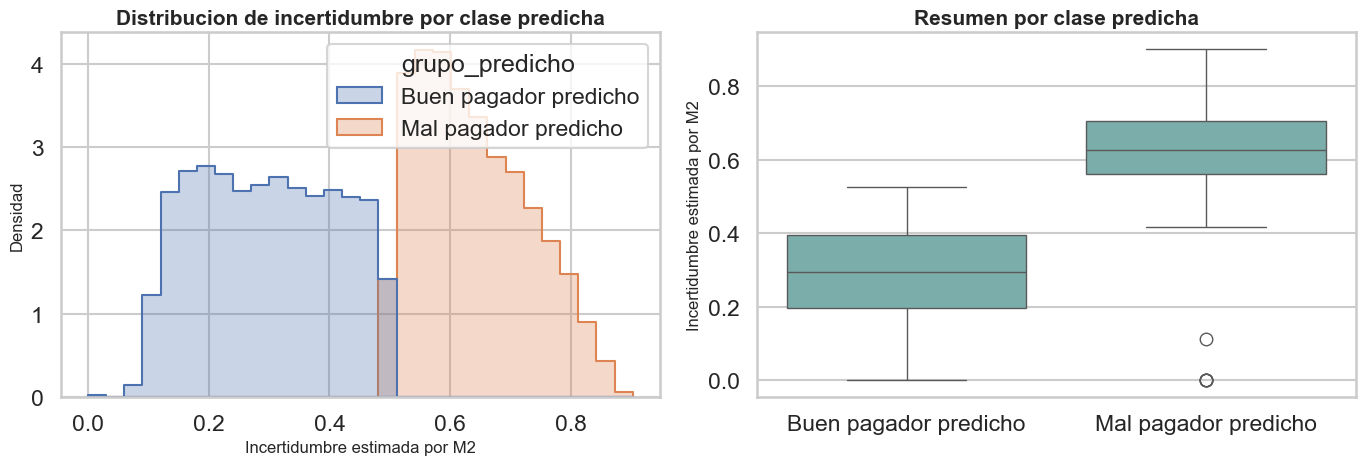

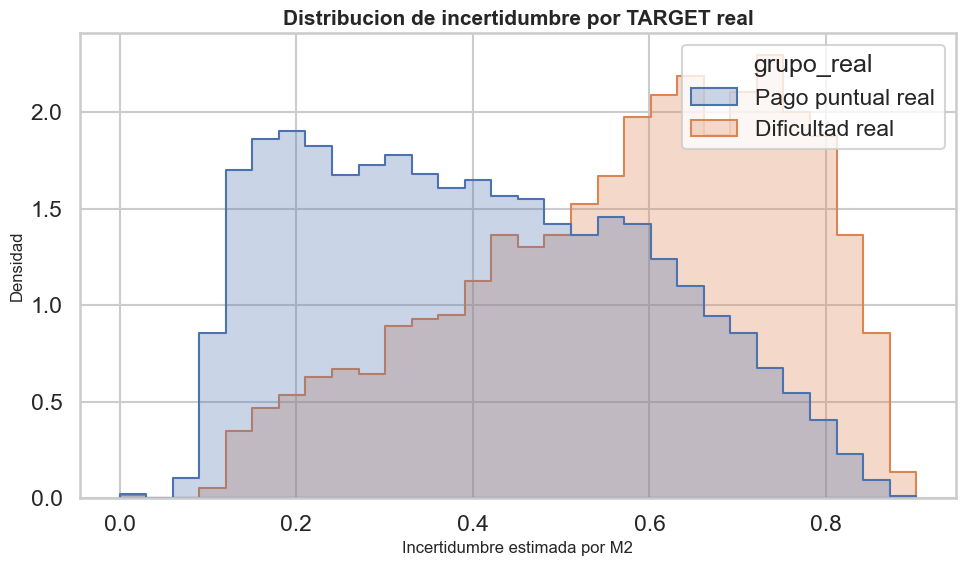

In [25]:
unc["grupo_predicho"] = unc["y_pred_label"].map({0: "Buen pagador predicho", 1: "Mal pagador predicho"})
unc["grupo_real"] = unc["y_true"].map({0: "Pago puntual real", 1: "Dificultad real"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_predicho",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
    ax=axes[0],
)
axes[0].set_title("Distribucion de incertidumbre por clase predicha")
axes[0].set_xlabel("Incertidumbre estimada por M2")
axes[0].set_ylabel("Densidad")

sns.boxplot(data=unc, x="grupo_predicho", y="uncertainty", color="#72B7B2", ax=axes[1])
axes[1].set_title("Resumen por clase predicha")
axes[1].set_xlabel("")
axes[1].set_ylabel("Incertidumbre estimada por M2")

plt.tight_layout()
save_figure("uncertainty_distribution_by_predicted_class.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_real",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
)
plt.title("Distribucion de incertidumbre por TARGET real")
plt.xlabel("Incertidumbre estimada por M2")
plt.ylabel("Densidad")
save_figure("uncertainty_distribution_by_target.png")
plt.show()

## 22. Calidad de datos: `EXT_NULL_COUNT` e incertidumbre

Este bloque valida una hipotesis clave: si faltan mas fuentes externas, el modelo deberia dudar mas. La auditoria usa `EXT_NULL_COUNT` crudo, no la matriz escalada, para evitar valores semanticamente imposibles.


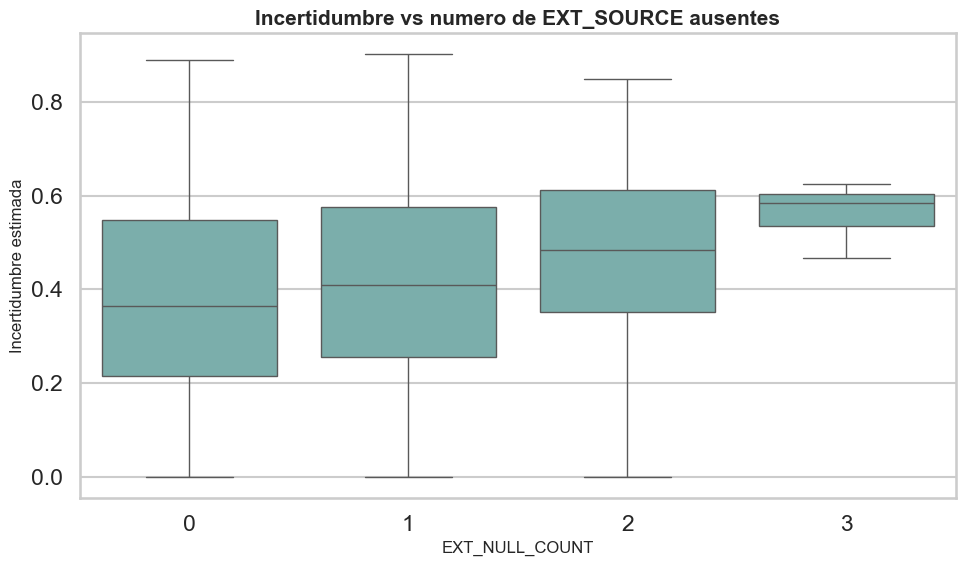

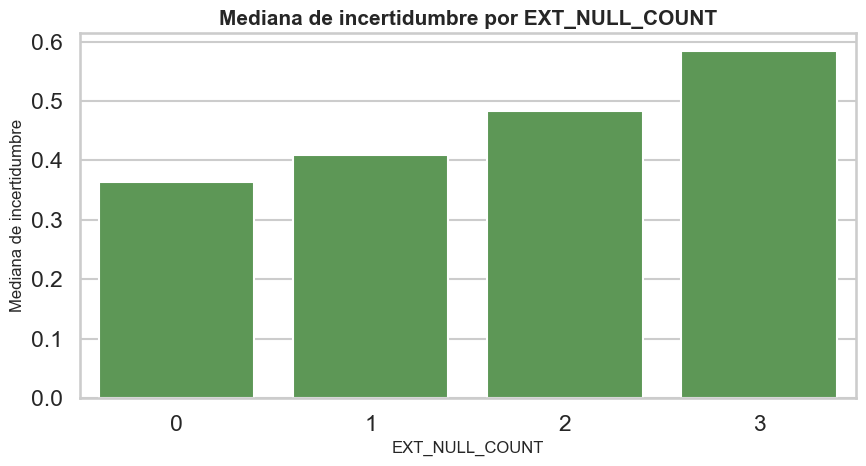

,EXT_NULL_COUNT,count,mean,median
0,0,16448,0.390181,0.363992
1,1,24140,0.422652,0.409465
2,2,5511,0.482478,0.484011
3,3,28,0.567813,0.584782


In [26]:
assert unc["uncertainty"].nunique() > 1, "M2 produjo incertidumbre constante."
assert set(unc["EXT_NULL_COUNT"].unique()).issubset({0, 1, 2, 3})

unc["EXT_NULL_COUNT"] = pd.Categorical(
    unc["EXT_NULL_COUNT"].astype(int),
    categories=[0, 1, 2, 3],
    ordered=True,
)

ext_unc_summary = (
    unc.groupby("EXT_NULL_COUNT", observed=False)["uncertainty"]
    .agg(count="count", mean="mean", median="median")
    .reset_index()
)
ext_unc_summary.to_csv(TABLES / "uncertainty_by_ext_null_count.csv", index=False)

plt.figure(figsize=(10, 6))
sns.boxplot(data=unc, x="EXT_NULL_COUNT", y="uncertainty", color="#72B7B2", order=[0, 1, 2, 3])
plt.title("Incertidumbre vs numero de EXT_SOURCE ausentes")
plt.xlabel("EXT_NULL_COUNT")
plt.ylabel("Incertidumbre estimada")
save_figure("ext_null_count_vs_uncertainty_boxplot.png")
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=ext_unc_summary, x="EXT_NULL_COUNT", y="median", color="#54A24B", order=[0, 1, 2, 3])
plt.title("Mediana de incertidumbre por EXT_NULL_COUNT")
plt.xlabel("EXT_NULL_COUNT")
plt.ylabel("Mediana de incertidumbre")
save_figure("ext_null_count_vs_uncertainty_median.png")
plt.show()

display(ext_unc_summary)

## 23. Ablación informacional: 12 vs 42 features

El MVP obligatorio usa el conjunto compacto de variables financieras, edad, género sensible y `EXT_SOURCE_*`. Como contraste informacional, se puede ampliar el análisis a las 122 columnas de `application_train.csv` y seleccionar un subconjunto de 42 variables mediante valores ausentes, correlación de Spearman, discriminancia tipo Cohen's d y encoding sin leakage.

| Comparación | Resultado observado | Interpretación |
|---|---:|---|
| Regresión logística, 12 -> 42 features | mejora aproximada de +0.017 AUC | La información adicional ayuda incluso a modelos lineales. |
| MLP con Dropout, 12 -> 42 features | mejora aproximada de +0.010 AUC | El techo del MVP no es solo arquitectura; también falta señal. |
| Modelo custom, 12 -> 42 features | mejora aproximada de +0.010 AUC | Las capas custom son auditables, pero el mayor salto viene de enriquecer datos. |

Esta sección no sustituye el MVP obligatorio. Sirve para argumentar el camino natural hacia una versión de mayor nota: formalizar `ExtendedFeaturePreprocessingPipeline`, integrar tablas relacionales y repetir la auditoría FAIR/incertidumbre sobre el dataset enriquecido.


,model,auc_12_features,auc_42_features,interpretation,auc_gain_42_vs_12,relative_auc_gain_pct
0,M0 logistic,0.7335,0.7501,La senal adicional ayuda incluso a un modelo l...,0.0166,2.2631
1,M3 dropout,0.7457,0.7555,La regularizacion aprovecha mejor el espacio e...,0.0098,1.3142
2,M6 dual custom,0.7451,0.7550,El modelo auditable mejora cuando recibe mas i...,0.0099,1.3287


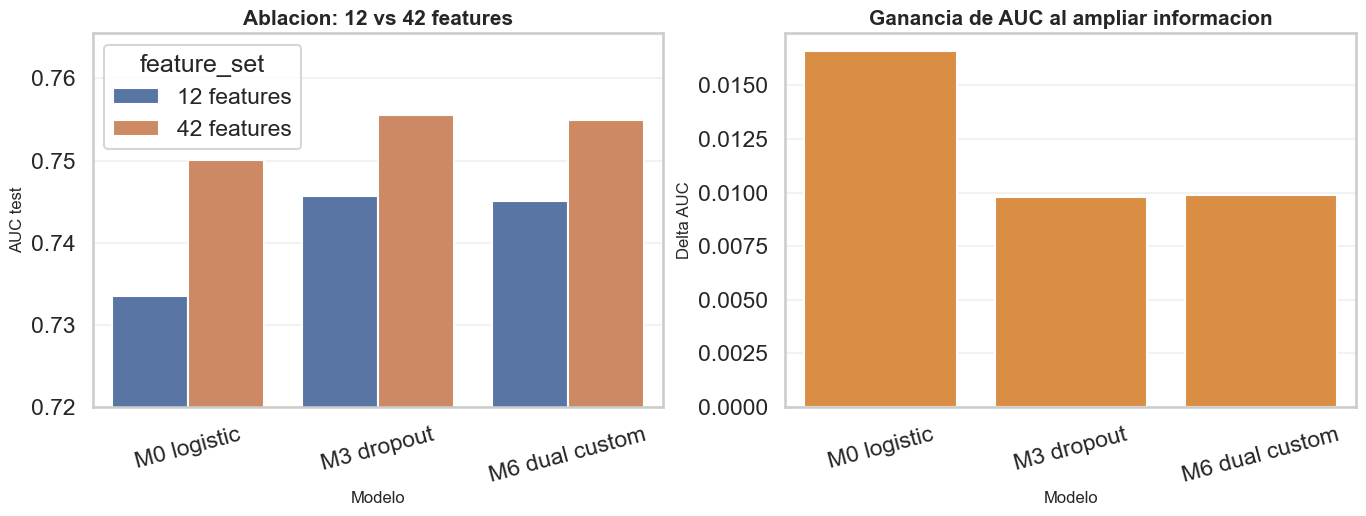

In [27]:
from src.trustworthy_credit.experiments import FeatureAblationReporter

feature_ablation = FeatureAblationReporter().summarize()
feature_ablation.to_csv(TABLES / "feature_ablation_12_vs_42.csv", index=False)

feature_ablation_display = feature_ablation.copy()
feature_ablation_numeric = feature_ablation_display.select_dtypes(include="number").columns
feature_ablation_display[feature_ablation_numeric] = feature_ablation_display[feature_ablation_numeric].round(4)
display(feature_ablation_display)

feature_ablation_plot = feature_ablation.melt(
    id_vars=["model"],
    value_vars=["auc_12_features", "auc_42_features"],
    var_name="feature_set",
    value_name="auc",
)
feature_ablation_plot["feature_set"] = feature_ablation_plot["feature_set"].map(
    {"auc_12_features": "12 features", "auc_42_features": "42 features"}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(
    data=feature_ablation_plot,
    x="model",
    y="auc",
    hue="feature_set",
    ax=axes[0],
)
sns.barplot(
    data=feature_ablation,
    x="model",
    y="auc_gain_42_vs_12",
    color="#F28E2B",
    ax=axes[1],
)
axes[0].set_title("Ablacion: 12 vs 42 features")
axes[1].set_title("Ganancia de AUC al ampliar informacion")
axes[0].set_xlabel("Modelo")
axes[1].set_xlabel("Modelo")
axes[0].set_ylabel("AUC test")
axes[1].set_ylabel("Delta AUC")
axes[0].set_ylim(0.72, max(feature_ablation_plot["auc"]) + 0.01)
for axis in axes:
    axis.tick_params(axis="x", rotation=15)
    axis.grid(alpha=0.25, axis="y")
save_figure("feature_ablation_12_vs_42_auc.png")
plt.show()


## 24. Conclusiones y limitaciones

El cierre resume los resultados trasladables a PDF y defensa: rendimiento, reducción de dependencia con género, incertidumbre M2, contraste MC Dropout, robustez multi-semilla y camino hacia una versión extendida con más información.


In [28]:
base_auc = float(test_results.loc[test_results["modelo"] == "Base final", "auc"].iloc[0])
fair_auc = float(test_results.loc[test_results["modelo"] == "FAIR final", "auc"].iloc[0])
base_rho = float(test_results.loc[test_results["modelo"] == "Base final", "abs_rho"].iloc[0])
fair_rho = float(test_results.loc[test_results["modelo"] == "FAIR final", "abs_rho"].iloc[0])

summary_lines = [
    f"Filas usadas: train={processed.X_train.shape[0]}, validation={processed.X_val.shape[0]}, test={processed.X_test.shape[0]}",
    f"Número de features procesadas: {len(feature_names)}",
    f"Mejor arquitectura: hidden_units={search_result.best_config.hidden_units}, activation={search_result.best_config.activation}, dropout={search_result.best_config.dropout:.2f}",
    f"AUC test base: {base_auc:.4f}",
    f"AUC test FAIR: {fair_auc:.4f}",
    f"|rho| test base: {base_rho:.4f}",
    f"|rho| test FAIR: {fair_rho:.4f}",
    f"Diferencia AUC FAIR-base: {fair_auc - base_auc:.4f}",
    f"Reducción |rho| base-FAIR: {base_rho - fair_rho:.4f}",
]

for line in summary_lines:
    print("-", line)

pd.Series(summary_lines, name="resumen_mvp").to_csv(TABLES / "mvp_executive_summary.csv", index=False)

display(test_results)
display(pareto)

- Filas usadas: train=215254, validation=46126, test=46127
- Número de features procesadas: 36
- Mejor arquitectura: hidden_units=(256, 64, 128, 128), activation=elu, dropout=0.20
- AUC test base: 0.7436
- AUC test FAIR: 0.7380
- |rho| test base: 0.0971
- |rho| test FAIR: 0.0088
- Diferencia AUC FAIR-base: -0.0056
- Reducción |rho| base-FAIR: 0.0882


,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.481516,0.743631,0.222811,0.657186,0.150990,0.702202,0.248539,0.097065,0.088874,0.080517
1,FAIR final,5.0,0.500768,0.738022,0.218571,0.674291,0.154138,0.676155,0.251047,0.008850,0.024762,0.015300


,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True
